Which products/categories should we recommend to valuable customers based on what they already buy?

In [1]:
# loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("Data/customers.csv")
orders = pd.read_csv("Data/orders.csv")
order_items = pd.read_csv("Data/order_items.csv")
products = pd.read_csv("Data/products.csv")

critical_customers = pd.read_csv(
    "Data/critical_customers.csv"
)

retention_actions = pd.read_csv(
    "Data/customer_retention_actions.csv"
)

print("Opportunity analysis data loaded successfully.")

Opportunity analysis data loaded successfully.


In [2]:
# Identify products purchased by Critical customers
critical_orders = orders[
    orders["customer_id"].isin(
        critical_customers["customer_id"]
    )
].copy()


In [3]:
critical_order_items = critical_orders[
    ["order_id", "customer_id"]
].merge(
    order_items,
    on="order_id",
    how="inner"
)

In [4]:
critical_order_items = critical_order_items.merge(
    products[
        [
            "product_id",
            "product_name",
            "category",
            "sub_category",
            "brand"
        ]
    ],
    on="product_id",
    how="left"
)

In [5]:
# Find categories each customer has purchased
customer_categories = (
    critical_order_items[
        [
            "customer_id",
            "category"
        ]
    ]
    .drop_duplicates()
)

customer_categories.head()

,customer_id,category
0,CUST030558,Beauty
1,CUST043927,Fashion
2,CUST043927,Electronics
6,CUST043927,Beauty
7,CUST000840,Home & Kitchen


In [6]:
# Find category penetration
category_penetration = (
    customer_categories
    .groupby("category")
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)
# Calculate Penetration
category_penetration["penetration_pct"] = (
    category_penetration["customers"]
    / critical_customers["customer_id"].nunique()
    * 100
)
# Display:
category_penetration.sort_values(
    "penetration_pct",
    ascending=False
)

,category,customers,penetration_pct
1,Electronics,26,100.000000
2,Fashion,26,100.000000
0,Beauty,25,96.153846
3,Home & Kitchen,25,96.153846
4,Sports,23,88.461538


In [7]:
# Find customer-category gaps
#Which categories has a customer NOT purchased yet?
all_categories = products["category"].dropna().unique()

customer_ids = critical_customers[
    "customer_id"
].unique()

customer_category_matrix = pd.MultiIndex.from_product(
    [
        customer_ids,
        all_categories
    ],
    names=[
        "customer_id",
        "category"
    ]
).to_frame(index=False)

In [8]:
customer_category_matrix["purchased"] = (
    customer_category_matrix
    .merge(
        customer_categories.assign(purchased=1),
        on=["customer_id", "category"],
        how="left"
    )["purchased"]
    .fillna(0)
)

In [9]:
# Identify cross-sell opportunities
# We only want categories that the customer hasn't purchased.
cross_sell_gaps = (
    customer_category_matrix[
        customer_category_matrix["purchased"] == 0
    ]
    .drop(columns="purchased")
)

cross_sell_gaps.head(20)

,customer_id,category
73,CUST000840,Sports
88,CUST038293,Sports
92,CUST030963,Beauty
108,CUST014143,Sports
124,CUST040956,Home & Kitchen


In [10]:
# Prioritize the opportunity
# Not every missing category is equally useful.
cross_sell_opportunities = cross_sell_gaps.merge(
    critical_customers[
        [
            "customer_id",
            "total_revenue",
            "priority_score",
            "recency_days"
        ]
    ],
    on="customer_id",
    how="left"
)

In [11]:
# Create opportunity score
cross_sell_opportunities["opportunity_score"] = (
    cross_sell_opportunities["priority_score"]
    * (
        cross_sell_opportunities["total_revenue"]
        / cross_sell_opportunities["total_revenue"].max()
    )
)

In [12]:
# sort:-
cross_sell_opportunities = (
    cross_sell_opportunities
    .sort_values(
        "opportunity_score",
        ascending=False
    )
)

In [13]:
cross_sell_opportunities.head(20)

,customer_id,category,total_revenue,priority_score,recency_days,opportunity_score
1,CUST038293,Sports,98927.18,85.518798,355,85.518798
4,CUST040956,Home & Kitchen,68209.43,85.195793,326,58.741758
2,CUST030963,Beauty,59019.60,85.493450,379,51.005085
3,CUST014143,Sports,58594.94,85.412551,314,50.590174
0,CUST000840,Sports,50181.19,85.650984,526,43.446789


This is not a machine-learning prediction.

We are calling this an:- Opportunity Score

because we are ranking potential business opportunities based on existing customer value/risk—not claiming that the customer is statistically guaranteed to purchase.

In [14]:
# Find the strongest cross-sell categories
category_opportunity = (
    cross_sell_opportunities
    .groupby("category")
    .agg(
        potential_customers=("customer_id", "nunique"),
        opportunity_score=("opportunity_score", "sum")
    )
    .reset_index()
    .sort_values(
        "opportunity_score",
        ascending=False
    )
)

category_opportunity

,category,potential_customers,opportunity_score
2,Sports,3,179.555761
1,Home & Kitchen,1,58.741758
0,Beauty,1,51.005085


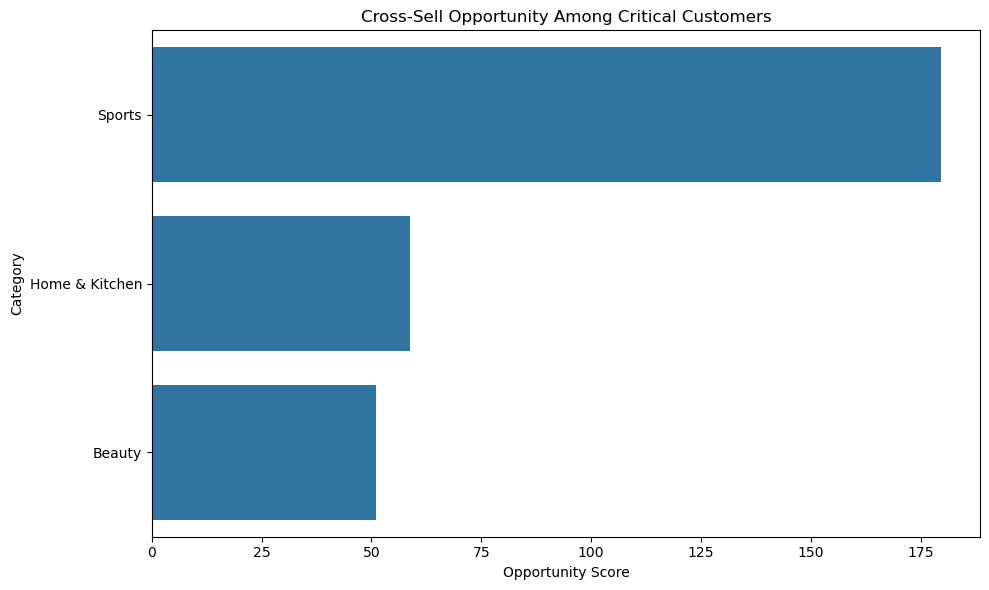

In [15]:
# Visualize opportunity
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_opportunity,
    x="opportunity_score",
    y="category"
)

plt.title(
    "Cross-Sell Opportunity Among Critical Customers"
)

plt.xlabel("Opportunity Score")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Sports has the biggest opportunity, with 3 high-priority customers and an opportunity score of 179.56.

This means the business should prioritize retention/re-engagement of these Sports customers, especially customers such as CUST038293.